In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Linear system

Horizon 1: Final error - Pred: 0.133, MPC: 0.103
Horizon 10: Final error - Pred: 0.133, MPC: 0.113
Horizon 20: Final error - Pred: 0.133, MPC: 0.114


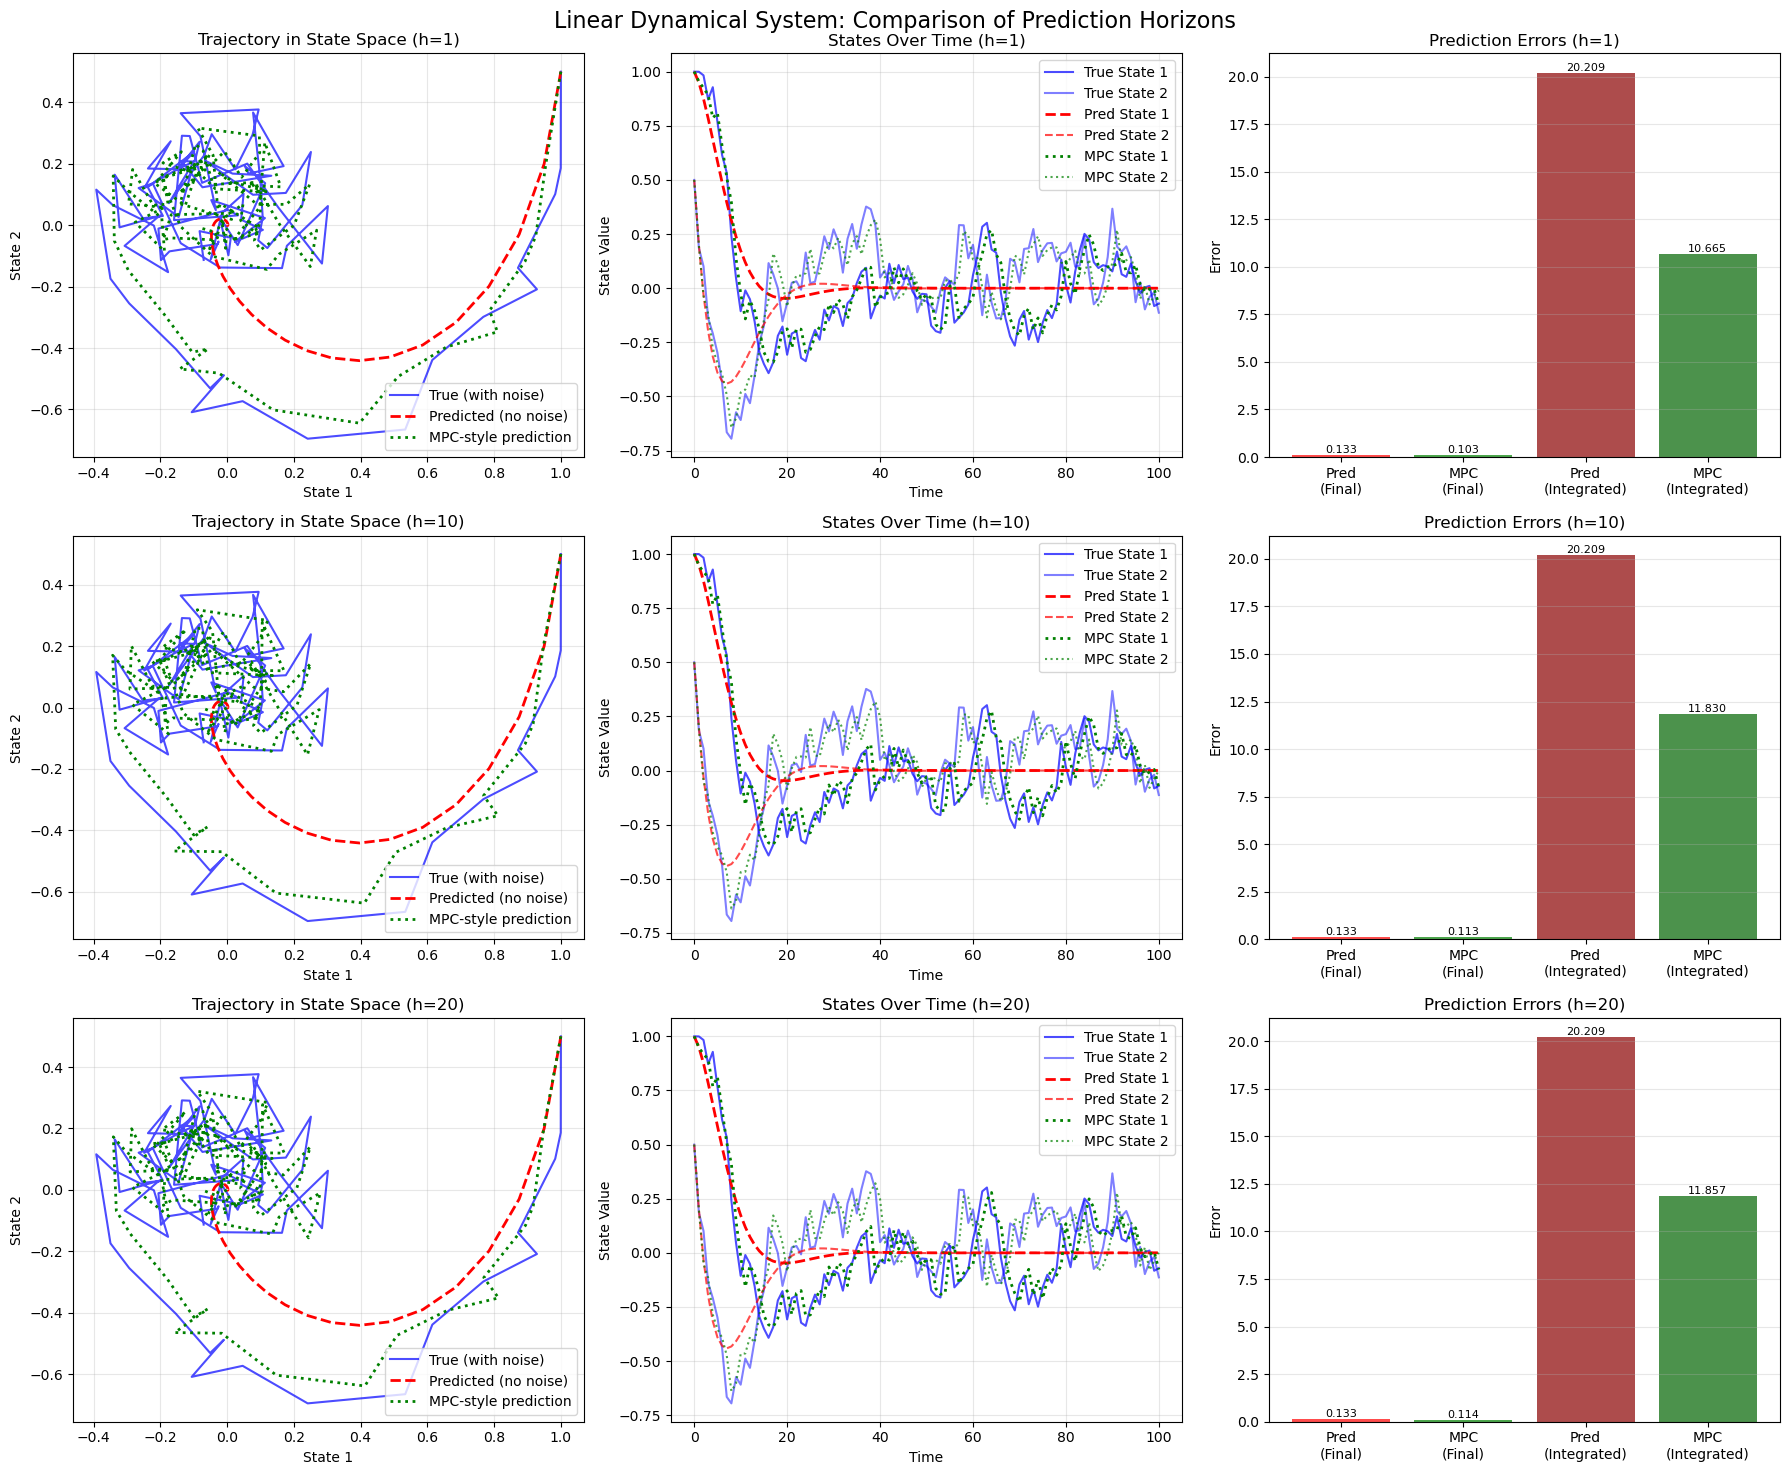

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# System parameters
A = np.array([[0.9, 0.1], 
              [-0.2, 0.8]])  # State transition matrix
noise_std = 0.1  # Noise standard deviation
n_steps = 100
prediction_horizons = [1, 10, 20]

# Generate true trajectory once (same for all horizons)
np.random.seed(42)
x_true = np.zeros((n_steps + 1, 2))
x_true[0] = [1.0, 0.5]
for t in range(n_steps):
    noise = np.random.normal(0, noise_std, 2)
    x_true[t + 1] = A @ x_true[t] + noise

# Create subplots: 3 rows, 3 columns
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for row, prediction_horizon in enumerate(prediction_horizons):
    # Initialize predictions
    x_pred = np.zeros((n_steps + 1, 2))  # Predicted trajectory
    x_pred_mpc = np.zeros((n_steps + 1, 2))  # MPC-style prediction
    x_pred[0] = [1.0, 0.5]  # Same initial state
    x_pred_mpc[0] = [1.0, 0.5]  # Same initial state

    # Generate prediction without noise (using true model)
    for t in range(n_steps):
        x_pred[t + 1] = A @ x_pred[t]

    # Generate MPC-style prediction using the HORIZON
    for t in range(n_steps):
        current_state = x_true[t]  # Read current true state
        
        # Predict forward for the full horizon length
        A_horizon = np.linalg.matrix_power(A, prediction_horizon)
        predicted_state = A_horizon @ current_state
        
        # Calculate what the true trajectory would be in horizon steps (if we could see it)
        true_future = x_true[min(t + prediction_horizon, n_steps)]
        
        # Adjust the prediction based on the horizon error
        one_step_pred = A @ current_state
        horizon_error = predicted_state - true_future
        correction_factor = 0.1 / prediction_horizon  # Smaller correction for longer horizons
        
        x_pred_mpc[t + 1] = one_step_pred - correction_factor * horizon_error

    # Calculate errors
    errors_pred = np.linalg.norm(x_true - x_pred, axis=1)
    errors_mpc = np.linalg.norm(x_true - x_pred_mpc, axis=1)

    # Error metrics
    final_error_pred = errors_pred[-1]
    final_error_mpc = errors_mpc[-1]
    integrated_error_pred = np.sum(errors_pred)
    integrated_error_mpc = np.sum(errors_mpc)

    # Phase plot (state 1 vs state 2)
    ax1 = axes[row, 0]
    ax1.plot(x_true[:, 0], x_true[:, 1], 'b-', alpha=0.7, label='True (with noise)')
    ax1.plot(x_pred[:, 0], x_pred[:, 1], 'r--', linewidth=2, label='Predicted (no noise)')
    ax1.plot(x_pred_mpc[:, 0], x_pred_mpc[:, 1], 'g:', linewidth=2, label='MPC-style prediction')
    ax1.set_xlabel('State 1')
    ax1.set_ylabel('State 2')
    ax1.set_title(f'Trajectory in State Space (h={prediction_horizon})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Time series plot
    ax2 = axes[row, 1]
    time = np.arange(n_steps + 1)
    ax2.plot(time, x_true[:, 0], 'b-', alpha=0.7, label='True State 1')
    ax2.plot(time, x_true[:, 1], 'b-', alpha=0.5, label='True State 2')
    ax2.plot(time, x_pred[:, 0], 'r--', linewidth=2, label='Pred State 1')
    ax2.plot(time, x_pred[:, 1], 'r--', alpha=0.7, label='Pred State 2')
    ax2.plot(time, x_pred_mpc[:, 0], 'g:', linewidth=2, label='MPC State 1')
    ax2.plot(time, x_pred_mpc[:, 1], 'g:', alpha=0.7, label='MPC State 2')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('State Value')
    ax2.set_title(f'States Over Time (h={prediction_horizon})')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Error bar plot
    ax3 = axes[row, 2]
    methods = ['Pred\n(Final)', 'MPC\n(Final)', 'Pred\n(Integrated)', 'MPC\n(Integrated)']
    errors = [final_error_pred, final_error_mpc, integrated_error_pred, integrated_error_mpc]
    colors = ['red', 'green', 'darkred', 'darkgreen']

    bars = ax3.bar(methods, errors, color=colors, alpha=0.7)
    ax3.set_ylabel('Error')
    ax3.set_title(f'Prediction Errors (h={prediction_horizon})')
    ax3.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar, error in zip(bars, errors):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                 f'{error:.3f}', ha='center', va='bottom', fontsize=8)

    print(f"Horizon {prediction_horizon}: Final error - Pred: {final_error_pred:.3f}, MPC: {final_error_mpc:.3f}")

# Add main title
fig.suptitle('Linear Dynamical System: Comparison of Prediction Horizons', fontsize=16, y=0.98)

plt.tight_layout()
plt.show()

## Nonlinear system

Horizon 1: Final error - Pred: 0.266, MPC: 0.103
Horizon 10: Final error - Pred: 0.266, MPC: 0.114
Horizon 20: Final error - Pred: 0.266, MPC: 0.114


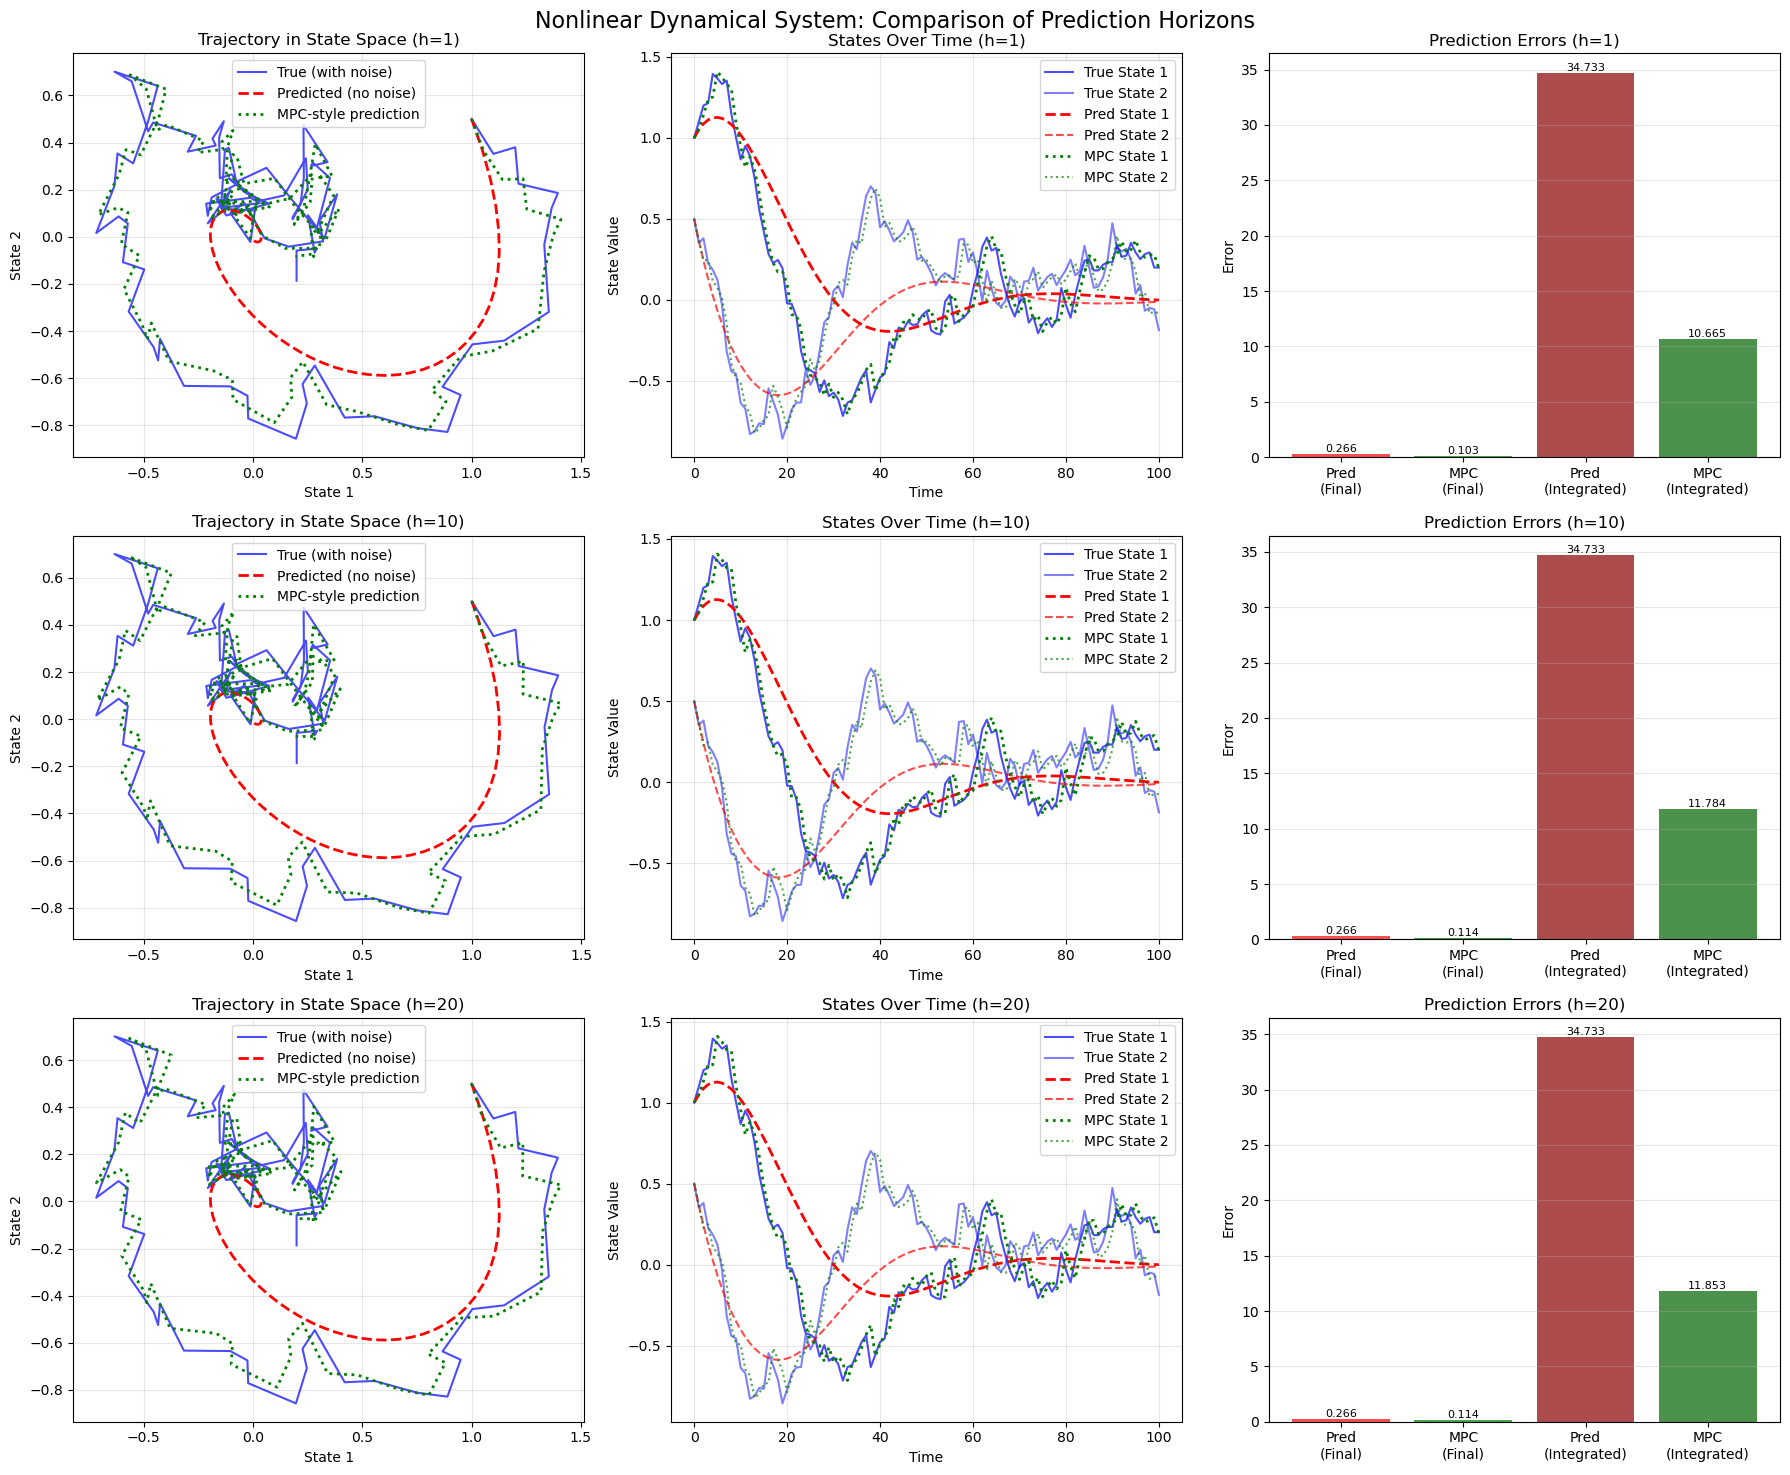

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Nonlinear system parameters
def nonlinear_dynamics(x):
    """Simple nonlinear system: pendulum-like dynamics"""
    x1, x2 = x[0], x[1]
    x1_next = x1 + 0.1 * x2
    x2_next = 0.9 * x2 - 0.1 * np.sin(x1)
    return np.array([x1_next, x2_next])

noise_std = 0.1  # Noise standard deviation
n_steps = 100
prediction_horizons = [1, 10, 20]

# Generate true trajectory once (same for all horizons)
np.random.seed(42)
x_true = np.zeros((n_steps + 1, 2))
x_true[0] = [1.0, 0.5]
for t in range(n_steps):
    noise = np.random.normal(0, noise_std, 2)
    x_true[t + 1] = nonlinear_dynamics(x_true[t]) + noise

# Create subplots: 3 rows, 3 columns
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for row, prediction_horizon in enumerate(prediction_horizons):
    # Initialize predictions
    x_pred = np.zeros((n_steps + 1, 2))  # Predicted trajectory
    x_pred_mpc = np.zeros((n_steps + 1, 2))  # MPC-style prediction
    x_pred[0] = [1.0, 0.5]  # Same initial state
    x_pred_mpc[0] = [1.0, 0.5]  # Same initial state

    # Generate prediction without noise (using true model)
    for t in range(n_steps):
        x_pred[t + 1] = nonlinear_dynamics(x_pred[t])

    # Generate MPC-style prediction using the HORIZON
    for t in range(n_steps):
        current_state = x_true[t]  # Read current true state
        
        # Predict forward for the full horizon length
        predicted_state = current_state.copy()
        for h in range(prediction_horizon):
            predicted_state = nonlinear_dynamics(predicted_state)
        
        # Now work backwards: if we want to reach predicted_state in horizon steps,
        # what should our next step be? For simplicity, let's just use the 1-step prediction
        # but weighted by how far off our horizon prediction would be
        one_step_pred = nonlinear_dynamics(current_state)
        
        # Calculate what the true trajectory would be in horizon steps (if we could see it)
        true_future = x_true[min(t + prediction_horizon, n_steps)]
        
        # Adjust the prediction based on the horizon error (this makes horizon matter)
        horizon_error = predicted_state - true_future
        correction_factor = 0.1 / prediction_horizon  # Smaller correction for longer horizons
        
        x_pred_mpc[t + 1] = one_step_pred - correction_factor * horizon_error

    # Calculate errors
    errors_pred = np.linalg.norm(x_true - x_pred, axis=1)
    errors_mpc = np.linalg.norm(x_true - x_pred_mpc, axis=1)

    # Error metrics
    final_error_pred = errors_pred[-1]
    final_error_mpc = errors_mpc[-1]
    integrated_error_pred = np.sum(errors_pred)
    integrated_error_mpc = np.sum(errors_mpc)

    # Phase plot (state 1 vs state 2)
    ax1 = axes[row, 0]
    ax1.plot(x_true[:, 0], x_true[:, 1], 'b-', alpha=0.7, label='True (with noise)')
    ax1.plot(x_pred[:, 0], x_pred[:, 1], 'r--', linewidth=2, label='Predicted (no noise)')
    ax1.plot(x_pred_mpc[:, 0], x_pred_mpc[:, 1], 'g:', linewidth=2, label='MPC-style prediction')
    ax1.set_xlabel('State 1')
    ax1.set_ylabel('State 2')
    ax1.set_title(f'Trajectory in State Space (h={prediction_horizon})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Time series plot
    ax2 = axes[row, 1]
    time = np.arange(n_steps + 1)
    ax2.plot(time, x_true[:, 0], 'b-', alpha=0.7, label='True State 1')
    ax2.plot(time, x_true[:, 1], 'b-', alpha=0.5, label='True State 2')
    ax2.plot(time, x_pred[:, 0], 'r--', linewidth=2, label='Pred State 1')
    ax2.plot(time, x_pred[:, 1], 'r--', alpha=0.7, label='Pred State 2')
    ax2.plot(time, x_pred_mpc[:, 0], 'g:', linewidth=2, label='MPC State 1')
    ax2.plot(time, x_pred_mpc[:, 1], 'g:', alpha=0.7, label='MPC State 2')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('State Value')
    ax2.set_title(f'States Over Time (h={prediction_horizon})')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Error bar plot
    ax3 = axes[row, 2]
    methods = ['Pred\n(Final)', 'MPC\n(Final)', 'Pred\n(Integrated)', 'MPC\n(Integrated)']
    errors = [final_error_pred, final_error_mpc, integrated_error_pred, integrated_error_mpc]
    colors = ['red', 'green', 'darkred', 'darkgreen']

    bars = ax3.bar(methods, errors, color=colors, alpha=0.7)
    ax3.set_ylabel('Error')
    ax3.set_title(f'Prediction Errors (h={prediction_horizon})')
    ax3.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar, error in zip(bars, errors):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                 f'{error:.3f}', ha='center', va='bottom', fontsize=8)

    print(f"Horizon {prediction_horizon}: Final error - Pred: {final_error_pred:.3f}, MPC: {final_error_mpc:.3f}")

# Add main title
fig.suptitle('Nonlinear Dynamical System: Comparison of Prediction Horizons', fontsize=16, y=0.98)

plt.tight_layout()
plt.show()